# Using mobilenet_v3_large as the backbone 

In [88]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import mobilenet_backbone
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.datasets import CocoDetection
from torchvision.transforms import v2 as T

# =======================
# 1. Dataset Paths
# =======================
train_images = '/home/aojwang/data/yolo_dataset/train/images'
train_ann = '/home/aojwang/data/yolo_dataset/train/coco_train.json'
val_images = '/home/aojwang/data/yolo_dataset/val/images'
val_ann = '/home/aojwang/data/yolo_dataset/val/coco_val.json'
test_images = '/home/aojwang/data/yolo_dataset/test/images'
test_ann = '/home/aojwang/data/yolo_dataset/test/coco_test.json'

# =======================
# 2. Transforms
# =======================
def get_transform():
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
    ])

# =======================
# 3. COCO Dataset Wrapper
# =======================
class CocoDetectionWithTransforms(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self.transforms = transforms

    def __getitem__(self, idx):
        img, _ = super().__getitem__(idx)
        image_id = self.ids[idx]
        target = {
            'image_id': torch.tensor(image_id),
            'boxes': [],
            'labels': []
        }

        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        for ann in anns:
            x, y, w, h = ann['bbox']
            if w < 1 or h < 1:
                continue
            target['boxes'].append([x, y, x + w, y + h])
            target['labels'].append(ann['category_id'])

        if len(target['boxes']) == 0:
            return self.__getitem__((idx + 1) % len(self))

        target['boxes'] = torch.tensor(target['boxes'], dtype=torch.float32)
        target['labels'] = torch.tensor(target['labels'], dtype=torch.int64)

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

# =======================
# 4. Load Datasets
# =======================
train_dataset = CocoDetectionWithTransforms(train_images, train_ann, get_transform())
val_dataset = CocoDetectionWithTransforms(val_images, val_ann, get_transform())
test_dataset = CocoDetectionWithTransforms(test_images, test_ann, get_transform())

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

# =======================
# 5. Create Model
# =======================
# Backbone with FPN
backbone = mobilenet_backbone(
    backbone_name='mobilenet_v3_large',
    weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
    fpn=True  # This adds 4 FPN layers by default
)

# Anchor generator with 3 levels to match FPN output
anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,)), 
    aspect_ratios=((0.5, 1.0, 2.0),) * 3 
)

# ImageNet mean and std for normalization
transform = GeneralizedRCNNTransform(
    min_size=640,
    max_size=1024,
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225]
)

# Number of classes (add 1 for background)
num_classes = len(train_dataset.coco.getCatIds()) + 1

# Full model
model = FasterRCNN(
    backbone=backbone,
    num_classes=num_classes,
    rpn_anchor_generator=anchor_generator,
    transform=transform
)

# =======================
# 6. Move to Device
# =======================
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# =======================
# 7. Optimizer & Scheduler
# =======================
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# =======================
# 8. Training Loop
# =======================
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    lr_scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"[Epoch {epoch+1}/{num_epochs}] 🔁 Avg Loss: {avg_loss:.4f}")

# =======================
# 9. Save Trained Model
# =======================
torch.save(model.state_dict(), "fasterrcnn_mobilenetv3.pth")
print("✅ Model saved as fasterrcnn_mobilenetv3.pth")


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Epoch 1/20] 🔁 Avg Loss: 0.4890
[Epoch 2/20] 🔁 Avg Loss: 0.3557
[Epoch 3/20] 🔁 Avg Loss: 0.3258
[Epoch 4/20] 🔁 Avg Loss: 0.2496
[Epoch 5/20] 🔁 Avg Loss: 0.2302
[Epoch 6/20] 🔁 Avg Loss: 0.2237
[Epoch 7/20] 🔁 Avg Loss: 0.2100
[Epoch 8/20] 🔁 Avg Loss: 0.2082
[Epoch 9/20] 🔁 Avg Loss: 0.2084
[Epoch 10/20] 🔁 Avg Loss: 0.2061
[Epoch 11/20] 🔁 Avg Loss: 0.2061
[Epoch 12/20] 🔁 Avg Loss: 0.2064
[Epoch 13/20] 🔁 Avg Loss: 0.2058
[Epoch 14/20] 🔁 Avg Loss: 0.2062
[Epoch 15/20] 🔁 Avg Loss: 0.2065
[Epoch 16/20] 🔁 Avg Loss: 0.2060
[Epoch 17/20] 🔁 Avg Loss: 0.2060
[Epoch 18/20] 🔁 Avg Loss: 0.2056
[Epoch 19/20] 🔁 Avg Loss: 0.2063
[Epoch 20/20] 🔁 Avg Loss: 0.2059
✅ Model saved as fasterrcnn_mobilenetv3.pth


# Grouped Bar Chart for Actual vs Predicted Class Frequencies
This does the following:
 * Compare two categories (actual vs predicted) side by side
 * Show how well the model’s predictions align with the ground truth for each class



In [92]:
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

def evaluate_and_count_labels(model, dataloader, device, threshold=0.5):
    model.eval()
    pred_label_counts = defaultdict(int)
    actual_label_counts = defaultdict(int)

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i in range(len(images)):
                actual_labels = targets[i]['labels'].cpu().numpy()
                for label in actual_labels:
                    actual_label_counts[label] += 1

                pred = outputs[i]
                pred_labels = pred['labels'].cpu().numpy()
                scores = pred['scores'].cpu().numpy()

                for label, score in zip(pred_labels, scores):
                    if score >= threshold:
                        pred_label_counts[label] += 1

    return actual_label_counts, pred_label_counts
    
# Get COCO class ID to name mapping from the dataset
coco = test_dataset.coco  # or val_dataset.coco
cat_id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(coco.getCatIds())}

import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(actual, predicted, id_to_name):
    # All unique labels in sorted order
    all_labels = sorted(set(actual.keys()).union(predicted.keys()))
    labels_names = [id_to_name.get(label, str(label)) for label in all_labels]
    actual_counts = [actual[label] for label in all_labels]
    predicted_counts = [predicted[label] for label in all_labels]

    x = np.arange(len(all_labels))  # positions
    width = 0.4  # width of each bar

    plt.figure(figsize=(20, 8))  # wider figure

    # Bar plots
    plt.bar(x - width/2, actual_counts, width=width, label='Actual', color='steelblue')
    plt.bar(x + width/2, predicted_counts, width=width, label='Predicted', color='darkorange')

    # X-ticks and labels
    plt.xticks(x, labels_names, rotation=90, fontsize=9, ha='center')
    plt.ylabel("Count")
    plt.title("Actual vs Predicted Labels (per class)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████| 90/90 [01:01<00:00,  1.47it/s]


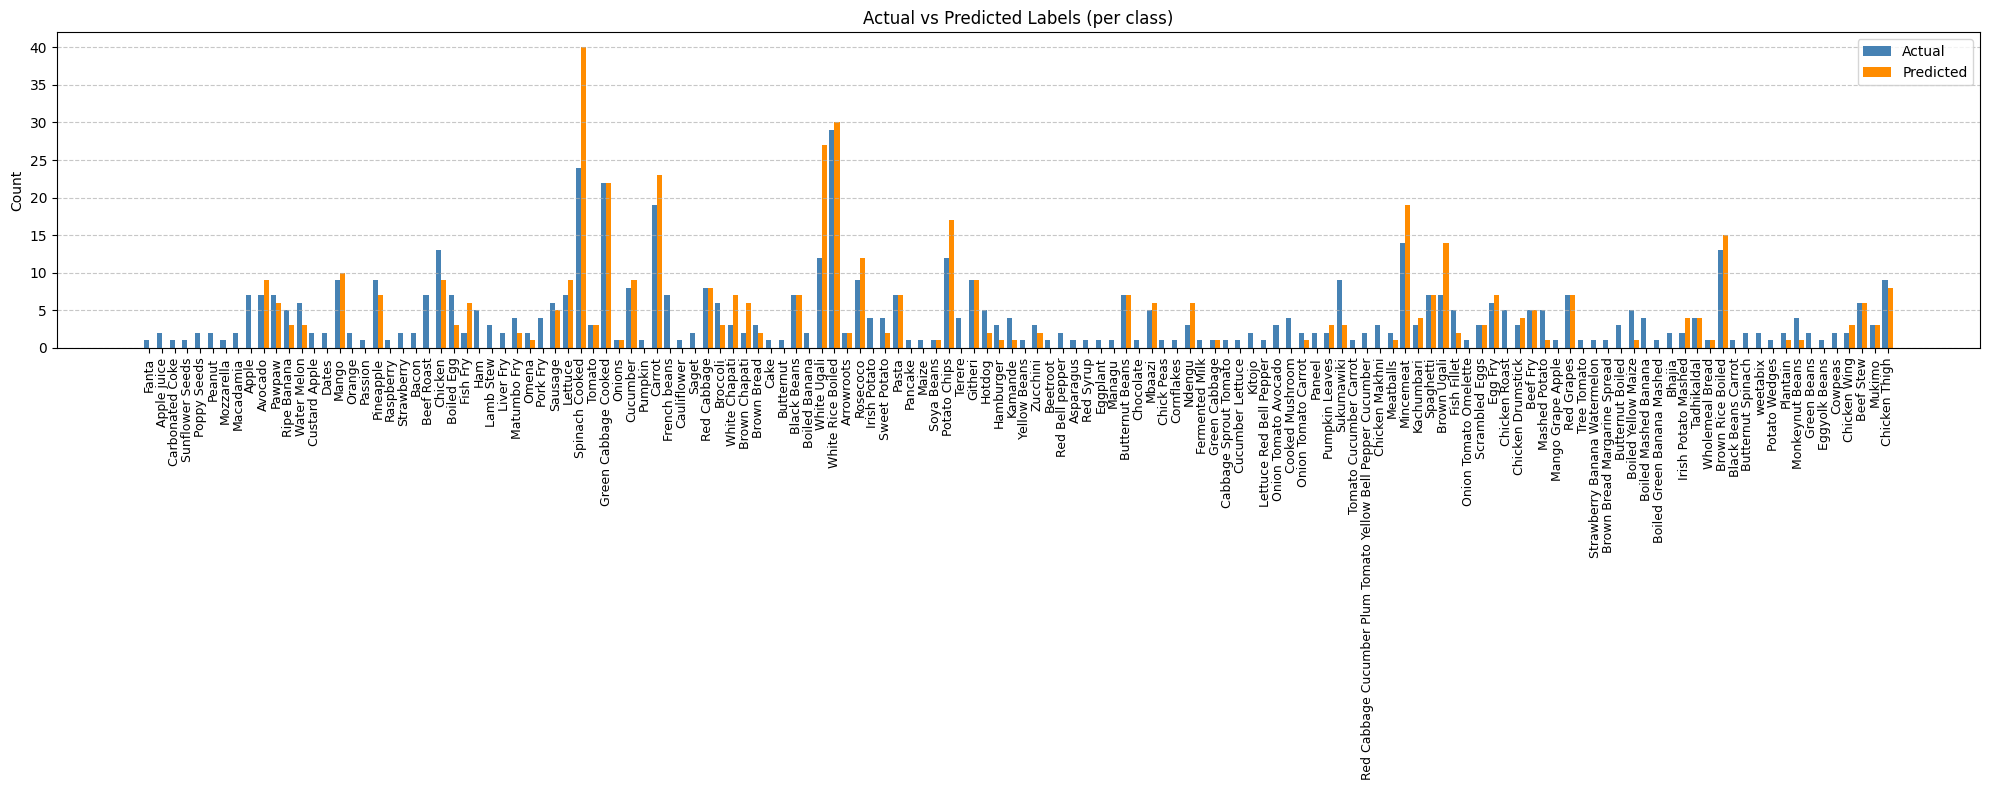

In [93]:
# Evaluate on validation or test set
actual_counts, pred_counts = evaluate_and_count_labels(model, test_loader, device)

# Plot
plot_actual_vs_predicted(actual_counts, pred_counts, cat_id_to_name)


# Scatter plot

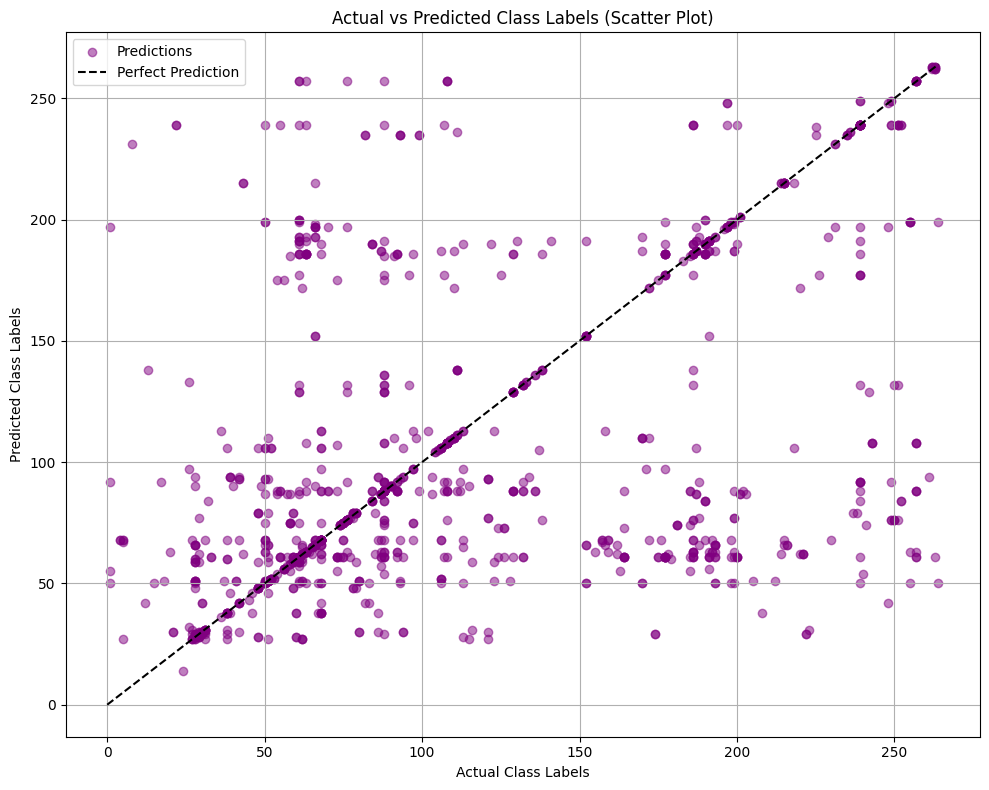

In [91]:
actual_labels = []
predicted_labels = []

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i, output in enumerate(outputs):
            pred_labels = output['labels'].cpu().tolist()
            true_labels = targets[i]['labels'].cpu().tolist()

            # Skip if any list is empty
            if not pred_labels or not true_labels:
                continue

            # Match lengths for a fair visual comparison
            min_len = min(len(pred_labels), len(true_labels))
            actual_labels.extend(true_labels[:min_len])
            predicted_labels.extend(pred_labels[:min_len])

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(actual_labels, predicted_labels, alpha=0.5, color='purple', label='Predictions')
plt.plot([0, max(actual_labels)], [0, max(actual_labels)], 'k--', label='Perfect Prediction')
plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# Load pretrained model

import torch
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import mobilenet_backbone
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.models import MobileNet_V3_Large_Weights

# Recreate model exactly as trained
def load_trained_model(weights_path="fasterrcnn_mobilenetv3.pth"):
    # 1. Rebuild the backbone with FPN
    backbone = mobilenet_backbone(
        backbone_name='mobilenet_v3_large',
        weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
        fpn=True
    )

    # 2. Rebuild anchor generator
    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 3
    )

    # 3. Rebuild the transform
    transform = GeneralizedRCNNTransform(
        min_size=640,
        max_size=1024,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225]
    )

    # 4. Set your num_classes as before
    num_classes = 265  # as used in training

    # 5. Reconstruct full model
    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        transform=transform
    )

    # 6. Load weights
    model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    model.eval()

    # 7. Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    return model

# ✅ Usage
model = load_trained_model("fasterrcnn_mobilenetv3.pth")


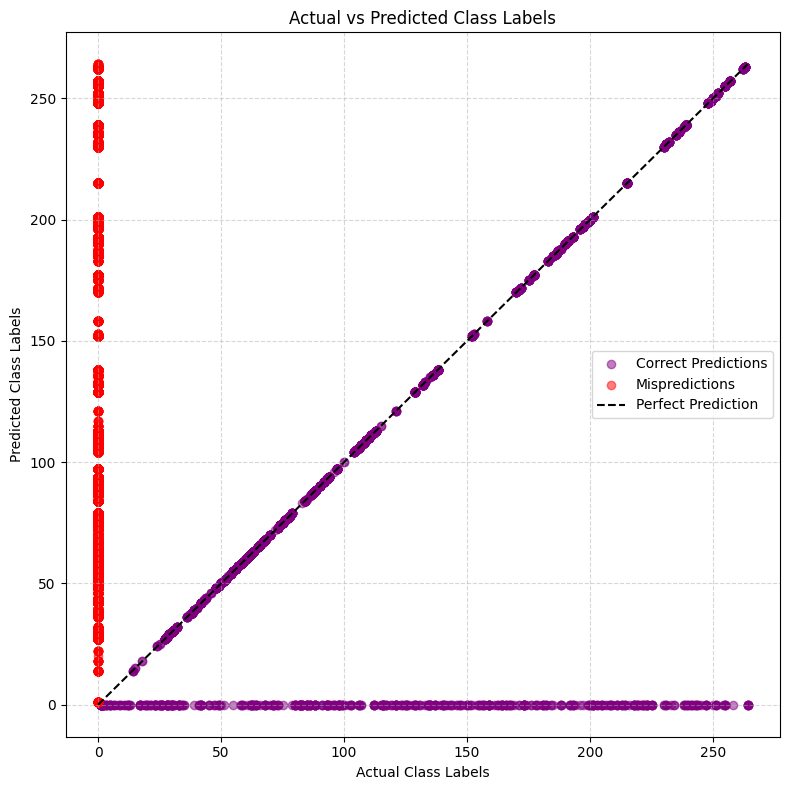

In [15]:
import torch
import matplotlib.pyplot as plt

actual_labels = []
predicted_labels = []
misactual_labels = []
mispredicted_labels = []

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i, output in enumerate(outputs):
            pred_labels = output['labels'].cpu().tolist()
            true_labels = targets[i]['labels'].cpu().tolist()

            # Skip if ground truth is empty (but track false positives)
            if not true_labels:
                mispredicted_labels.extend(pred_labels)
                misactual_labels.extend([0] * len(pred_labels))
                continue

            # Handle case where predictions are empty (false negatives)
            if not pred_labels:
                actual_labels.extend(true_labels)
                predicted_labels.extend([0] * len(true_labels))
                continue

            # Match predictions to ground truth
            matched_true = []
            matched_pred = []
            unmatched_pred = pred_labels.copy()
            
            for true_label in true_labels:
                if true_label in unmatched_pred:
                    matched_true.append(true_label)
                    matched_pred.append(true_label)
                    unmatched_pred.remove(true_label)
                else:
                    actual_labels.append(true_label)
                    predicted_labels.append(0)  # False negative
            
            # Add remaining unmatched predictions as false positives
            for false_pos in unmatched_pred:
                misactual_labels.append(0)
                mispredicted_labels.append(false_pos)
            
            # Add correct matches
            actual_labels.extend(matched_true)
            predicted_labels.extend(matched_pred)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(actual_labels, predicted_labels, alpha=0.5, color='purple', label='Correct Predictions')
plt.scatter(misactual_labels, mispredicted_labels, alpha=0.5, color='red', label='Mispredictions')

# Perfect prediction line
max_val = max(max(actual_labels or [0]), max(predicted_labels or [0]), 
             max(misactual_labels or [0]), max(mispredicted_labels or [0]))
min_val = min(min(actual_labels or [0]), min(predicted_labels or [0]), 
             min(misactual_labels or [0]), min(mispredicted_labels or [0]))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Accuracy
accuracy = np.mean(np.array(actual_labels) == np.array(predicted_labels))

# Precision, Recall, F1 Score
precision = precision_score(actual_labels, predicted_labels, average='macro', zero_division=0)
recall = recall_score(actual_labels, predicted_labels, average='macro', zero_division=0)
f1 = f1_score(actual_labels, predicted_labels, average='macro', zero_division=0)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision (Macro): {precision * 100:.2f}%")
print(f"Recall (Macro): {recall * 100:.2f}%")
print(f"F1 Score (Macro): {f1 * 100:.2f}%")


Accuracy: 85.84%
Precision (Macro): 50.85%
Recall (Macro): 45.10%
F1 Score (Macro): 46.93%
